In [1]:
import sys
sys.path.append('src/')
sys.path.append('src/fsrc/')
import ens

import skimage.measure as sm
from scipy import stats

import netCDF4 as ncdf
import numpy as np
import math as M
import glob
import sys
import os
import xarray as xr
import re

import matplotlib
import matplotlib.pyplot as P
from matplotlib import ticker
from matplotlib.offsetbox import AnchoredText

import json
from pyproj import Proj
from time import time as timer
from pyDart import dll_2_dxy, dxy_2_dll
import pyDart
import datetime as dt
from subprocess import *
#from cbook2 import *
import src.plot_src.ctables as ctables
from optparse import OptionParser
import scipy.interpolate
import scipy.ndimage as ndimage
import scipy.spatial


def findnearest(array, value):
    array = np.asarray(array)
    return (np.abs(array-value)).argmin()
    
# if options.fcst_file: # from a forecast run only
#     start_time = dt.datetime.strptime(exper['FORECAST']['start'], '%Y-%m-%d %H:%M:%S')
#     end_time   = dt.datetime.strptime(exper['FORECAST']['end'], '%Y-%m-%d %H:%M:%S')
#     timedel    = dt.timedelta(seconds = exper['FORECAST']['freq'])

# else: # from a typical experiment
#     timedel    = dt.timedelta(seconds = exper['forecast_freq'])
#     da_end     = dt.datetime.strptime(exper['DA_PARAMS']['DA_end_time'], '%Y-%m-%d %H:%M:%S') 
#     start_time = da_end #+ timedel
#     end_time   = da_end + dt.timedelta(seconds = exper['forecast_length']) 

# with open('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/Control/letkf.exp', 'rb') as f: exper = json.load(f)

# start_time = dt.datetime(2024, 5, 8, 21,30)
# end_time = dt.datetime(2024, 5, 8, 22,30)
# timedel = dt.timedelta(seconds=900)
# timearr = np.arange(start_time, end_time+timedel, timedel)
 

# for i, time in enumerate(timearr):
#     time = time.astype(dt.datetime)

#     files, myDT = ens.FindRestartFiles(exper, time, ret_exp=False, prior=False)
#     ens_state = ens.read_CM1_ens(files, exper, state_vector=None, DateTime=myDT, addmean=1) # the final member is the mean member!!!!
#     ens.ens_CM1_coords(ens_state)

#     if i == 0:
#         allvars = ens_state['state_vector']['xyz3d']

#         nt,nk,nj,ni,ne = len(timearr), ens_state['nz'],ens_state['ny'],ens_state['nx'],ens_state['ne']+1
        
#         coords = {'t'    : np.arange(0, nt),'ni'   : np.arange(0, ni),'nj'   : np.arange(0, nj),'nk'   : np.arange(0, nk), 'ne':np.arange(0,ne)}
#         data_vars = { 'time': (['t'], [t.astype(dt.datetime) for t in timearr]), 
#                       'xh': (['ni'], ens_state['xc'][:]/1000), 
#                       'yh': (['nj'], ens_state['yc'][:]/1000),
#                       'z' : (['nk'], ens_state['zc'][:]/1000)}
        
#         for v in allvars:
#             data_vars[v.lower()] = (['t','ne','nk','nj','ni'], np.zeros([nt,ne,nk,nj,ni])*np.nan)
#         myds = xr.Dataset(data_vars, coords)

#     for v in allvars:
#         myds[v.lower()][i,:,:,:,:] = ens_state[v][:]

#     del ens_state

# now add in 2-5 km UH
# z = myds.z
# ztop = findnearest(z, 5)
# zbot = findnearest(z, 2)

# # note = we are calculating this for the mean member as well
# w        = myds['w'][:, :, zbot:ztop+1].values
# u        = myds['u'][:, :, zbot:ztop+1].values
# v        = myds['v'][:, :, zbot:ztop+1].values

# dx  = np.gradient(myds.xh)*1000
# dy  = np.gradient(myds.yh)*1000
# dz  = np.gradient(myds.z)[zbot:ztop+1]*1000

# dudy = np.gradient(u, axis=3)/dy
# dvdx = np.gradient(v, axis=4)/dx
# zeta = dvdx-dudy

# UH = np.sum(zeta*w*dz[np.newaxis, np.newaxis, :, np.newaxis, np.newaxis], axis=2)
# del u,v,dx,dy,dz,dudy, dvdx, zeta

# myds['UH_2-5km'] = (('t', 'ne','nj','ni'), UH)

# myds['w_2-5km'] = (('t', 'ne', 'nj', 'ni'), w.mean(axis=2))

# del w

# myds.to_netcdf(exper['base_path']+'/full_ens_fcst.nc', format='NETCDF4')

In [83]:
sorted(exps)

['/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C10_3L07_R0',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C10_3L09_R0',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C10_3L12_R0',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C10_5L07_R0',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C10_5L07_R0_V2',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C10_5L07_R0_V6',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C10_5L09_R0',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C10_5L09_R0_V2',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C10_5L09_R0_V2_dense',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C10_5L09_R0_V2_lowtop',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C10_5L09_R0_V2_noAI',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C10_5L09_R0_V6',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C10_5L12_R0',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C10_5L15_R0',
 '/work/jessica.mcdonald/CM1_LETKF_20

# Out file Quick Check

In [84]:
filename = 'DBZ_VR.out'

exps = [f'C3_5L{h:02d}_R0' for h in [7,9,12,15,18]]

exps = [f'C{m}_5L09_R0' for m in [2,1]]

#exps=['C2_5L09_R0_V2','C3_5L09_R0','C3_5L09_R0_H6']

exps=['C3_5L07_R5', 'C3_5L07_R5_test2']

exps = sorted(glob.glob('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C*'))
# exps

for exp in exps:
    #print(exp)
    filename=exp+'/letkf.out'#f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/letkf.out' #exp+'/letkf.out'#
    print(exp)
    with open(filename, 'r') as file:
        for line_number, line in enumerate(file, start=1):
            if '!!! ERROR' in line:
                
                print(f"Line {line_number}: {line.strip()}")


/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C10_3L07_R0
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C10_3L09_R0
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C10_3L12_R0
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C10_5L07_R0
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C10_5L07_R0_V2
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C10_5L07_R0_V6
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C10_5L09_R0
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C10_5L09_R0_V2
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C10_5L09_R0_V2_dense
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C10_5L09_R0_V2_lowtop
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C10_5L09_R0_V2_noAI
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C10_5L09_R0_V6
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C10_5L12_R0
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C10_5L15_R0
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C10_5L18_R0
/work/jessica.mcdonald/CM1_LETK

In [6]:
for exp in exps:
    #print(exp)
    #filename=f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/letkf.out' #exp+'/letkf.out'#
    filename = f'/work/jessica.mcdonald/CM1_LETKF_2025/run/letkf.out'
    
    with open(filename, 'r') as file:
        for line_number, line in enumerate(file, start=1):
            if 'ERROR' in line:
                print(exp)
                print(f"Line {line_number}: {line.strip()}")

# CM1 outfile Quick Check

In [1]:
#cm1.out files are deleted if you're redoing a DA experiment without rerunning the "spin up" time, so these won't contain old errors
experiment = '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min'

import glob 
files = sorted(glob.glob(f'{experiment}/member*/cm1.out'))
for f in files:
    print(f.split('/')[-2])
    with open(f, 'r') as file:
        for line_number, line in enumerate(file, start=1):
            if 'error' in line:
                print(f"Line {line_number}: {line.strip()}")
            if 'denied' in line:
                print(f"Line {line_number}: {line.strip()}")

member001
Line 98968: netcdf status returned an error:           13  ... stopping program
Line 98970: Permission denied
member002
member003
member004
member005
member006
member007
member008
member009
member010
member011
member012
member013
member014
member015
member016
member017
member018
member019
member020
member021
member022
member023
member024
member025
member026
member027
member028
member029
member030
member031
member032
member033
member034
member035
member036


# update the name/filepaths of an experiment

In [1]:
import sys
import os
import glob
import json

In [80]:
exps = [f'C3_h{h:02d}_R0' for h in [7,9,12,15,18]]

exps = ['C3_5L09_R0_H2','C3_5L09_R0_H6','C2_5L09_R0_H2','C2_5L09_R0_H6']
exps = ['C3_3L09_R0_V2_periodic']
for exp in exps:
    new_name = 'C3_5L09_R0_V2_periodic'#exp.replace('H', 'V')
    print(new_name)

C3_5L09_R0_V2_periodic


In [7]:
exps = ['C3_h18_R1','C3_h18_R3','C3_h18_R5','C3_h18_R7','C3_h18_R9']

In [3]:
base_path = '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/'
#exps = [f'C10_h{h:02d}_R0' for h in [7,9,12,15,18]]
#for files in glob.glob('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI*'):
exps = ['C3_3L09_R0_V2_periodic']
for exp in exps:
    new_name = 'C3_5L09_R0_V2_periodic'
    # exp = os.path.basename(files)
    # print(exp)
    
    #new_name = 'C3_h18_R9'#exp[:-1]+'N'#'CI_3min_R05_noAI'#exp+'_noAI'
    
    curr_path = os.path.join(base_path, exp)
    new_path  = os.path.join(base_path, new_name)

    print(f'moving {curr_path} to {new_path}')
    
    ## ---------------------------------------------------
    # STEP ONE
    # update file paths in the json file
    
    fjson = glob.glob(os.path.join(curr_path, '*.exp'))[0]
    with open(fjson, 'rb') as f:exper= json.load(f)
    
    for var in ['base_dir', 'namelist', 'base_path', 'fcst_path', 'plots_path']: 
        exper[var] = exper[var].replace(curr_path, new_path)
    
    # then do forecast members
    fcst_mems = []
    for f in exper['fcst_members']:
        fcst_mems.append(f.replace(curr_path, new_path))
    exper['fcst_members'] = fcst_mems
    
    with open(fjson, 'w') as f: json.dump(exper, f)
    
    # temporary step, change name to "letkf.exp"
    # newjson = os.path.join(curr_path, 'letkf.exp')
    # os.system(f'mv {fjson} {newjson}')
    
    ## ---------------------------------------------------
    # STEP TWO 
    # check for any forecast files 
    
    fcsts = glob.glob(os.path.join(curr_path, "FORECAST*"))
    for fcst in fcsts:
        
        new_fcst = fcst.replace(fcst, fcst.replace(exp, new_name))
        print(f'moving {fcst} to {new_fcst}')
        
        
        fjson = glob.glob(os.path.join(fcst, '*.exp'))[0]
        with open(fjson, 'rb') as f:exper= json.load(f)
    
        for var in ['base_dir', 'namelist', 'base_path', 'fcst_path', 'plots_path']: 
            exper[var] = exper[var].replace(fcst,  new_fcst)
    
        # then do forecast members
        fcst_mems = []
        for f in exper['fcst_members']:
            fcst_mems.append(f.replace(fcst, new_fcst))
        exper['fcst_members'] = fcst_mems
    
    
        with open(fjson, 'w') as f: json.dump(exper, f)
    
        # temporary step, change name to "fcst.exp"
        #newjson = os.path.join(fcst, 'fcst.exp')
        #os.system(f'mv {fjson} {newjson}')
    
    ## ---------------------------------------------------
    # STEP THREE
    # move the old experiment to the new filename
    
    os.system(f'mv {curr_path} {new_path}')

    print('finished')


moving /work/jessica.mcdonald/CM1_LETKF_2025/experiments/C3_3L09_R0_V2_periodic to /work/jessica.mcdonald/CM1_LETKF_2025/experiments/C3_5L09_R0_V2_periodic
finished


In [13]:
new_name[:-1]+'N'

'CI_3min_R05_noAN'

In [2]:
### needed to make the soundings a little taller 

# import pandas as pd
# files = sorted(glob.glob('/work/jessica.mcdonald/CM1_LETKF_2025/run/soundings/Run*.txt'))
# for fi in files:
#     with open(fi, 'r') as f:
#         lines = f.readlines()
#         if lines:  # Check if the file is not empty
#             last_line = lines[-1].strip().split('\t')
#     last_line[0] = '26050.00'
    
#     with open(fi, 'a') as f:
#         f.write(f'{last_line[0]}\t{last_line[1]}\t{last_line[2]}\t{last_line[3]}\t{last_line[4]}')

# Monitor ongoing experimets
## 1. Plot Prior and Posterior compared to obs
## 2. Check stats files
## 3. Overview of a single member 

In [5]:
import sys
import os
import numpy as N
import math as M
import datetime as DT 
from netCDF4 import *
import datetime

import glob
from optparse import OptionParser
from multiprocessing import Pool
from time import time as timer
#from nc_prior_file import *
#from assim_util import *

sys.path.append('src/')
sys.path.append('fsrc/')
import state_vector as state
import json
import src.plot_src.ctables as ctables

import ens 
from pyDart import dxy_2_dll
import pandas as pd
import pickle
import numpy as np
import cftime
from fpython2 import fstate, addbubbles_box, obs_2_grid3d

import contextlib
import io

def findnearest(array, value):
    array = np.asarray(array)
    return (np.abs(array-value)).argmin()

def get_dbz(analysis_time, fpath):
    name = fpath.split('/')[-2]
    myDTstring = analysis_time.strftime('%Y,%m,%d,%H,%M,%S')
    with open(f'{fpath}{name}.exp', 'rb') as f:
        exper = json.load(f)
    files, myDT = ens.FindRestartFiles(exper, myDTstring, ret_exp=False,);
    
    mystate = ens.read_CM1_ens(files, exper, state_vector=state.Hxf, DateTime=analysis_time)   
    ens.ens_CM1_C2A(mystate)
    ens.ens_CM1_coords(mystate)
    
    obs = ens.ens_GRID_RELECTIVITY(mystate)
    return obs

import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl    
plt.rc('xtick', labelsize=14) 
plt.rc('ytick', labelsize=14) 
plt.rc('axes', labelsize=14, titlesize=18) 
mpl.rcParams.update({"axes.grid" : False, "grid.color": "0.6",  'grid.linestyle':':',
                    'grid.linewidth':1, 'axes.labelweight':'bold', 'legend.framealpha':1.0})

In [17]:
from ens import mymap
import scipy

In [6]:
#===============================================================================
from ens import mymap
import scipy
def get_dbz_fast(analysis_time, fpath, cref=True, ob_file=None):

    if fpath[-1]=='/': fpath=fpath[:-1]
    name = os.path.basename(fpath)
    
    with open(f'{fpath}/{name}.exp', 'rb') as f: exper = json.load(f)
    
    # These values are set in the experiment dictionary created at the begining of the run
    
    xoffset = exper['xoffset']
    yoffset = exper['yoffset']
    glat    = exper['lat0']
    glon    = exper['lon0']
      
    if ob_file == None:
      ob_file = exper['radar_obs']
    
    ob_f = pd.read_csv(ob_file)
    
    # look for reflectivity +/- 2.5 min 
    
    dt            = datetime.timedelta(0,30)
    begin  = cftime.date2num(analysis_time - dt, "seconds since 1970-01-01 00:00:00")
    ending = cftime.date2num(analysis_time + dt, "seconds since 1970-01-01 00:00:00")
    
    data_mask = (ob_f.utime >= begin) & (ob_f.utime <= ending) &(ob_f.kind==12) # only dbz
    
    odata = ob_f[data_mask]
    
    data    = odata['value'][:]
    lats    = odata['lat'][:]
    lons    = odata['lon'][:]
    hgts    = odata['height'][:]
    
    cm1 = exper['cm1namelist']
    names = [c[1] for c in cm1]
    nx=cm1[np.where(np.array(names)=='nx')[0][0]][2]
    ny=cm1[np.where(np.array(names)=='ny')[0][0]][2]
    nz=cm1[np.where(np.array(names)=='nz')[0][0]][2]
    dx=cm1[np.where(np.array(names)=='dx')[0][0]][2]
    
    fstate_xc = np.arange(0, nx*dx, dx) + dx/2
    fstate_xc += exper['xoffset']
    fstate_yc = np.arange(0, ny*dx, dx) + dx/2
    fstate_yc += exper['yoffset']
    
    temp = xr.open_dataset(sorted(glob.glob(f"{exper['fcst_members'][0]}/*.nc"))[0], decode_timedelta=True)
    fstate_zc=temp.zh.values
    temp.close()
    
    map      = mymap(fstate_xc, fstate_yc, glat, glon)
    xob, yob = map(lons, lats)
    xob, yob = xob+xoffset, yob+yoffset
    
    # The coordinate system here is based on the grid lat0/lon0/hgt0, and the offset grid stored in fstate
    #     ens stores the x/y grid in grid-internal coordinates
    # Create obs list for KDTree query...
    xyz_obs  = np.vstack((hgts,yob,xob))
    obs_list = list(xyz_obs.transpose())
    
    # Create 3D grid arrays for KDTree
    y_array, z_array, x_array = np.meshgrid(fstate_yc, fstate_zc, fstate_xc)
    xyz_grid = np.dstack([z_array.ravel(),y_array.ravel(),x_array.ravel()])[0]
      
    # Use cKDTree to create fast indexing for 3D grid....
    
    mytree = scipy.spatial.cKDTree(xyz_grid)
    distance, indices1D = mytree.query(obs_list)
    
    # these are the integer indices that you now pass into the fortran routine. They
    # are the un-raveled 3D index locations nearest the observation point in the 3D array
    
    kk,jj,ii = np.unravel_index(indices1D, (len(fstate.zc), len(fstate.yc), len(fstate.xc))) 
    dbz3d = obs_2_grid3d(data, xob, yob, hgts, x_array, y_array, z_array, ii, jj, kk, 4000., 2000., 0.0)

    # Create composite reflectivity, and then replicate it into a 3D array
    
    dbz2d = np.zeros((1,))
    
    if cref:
    
        dbz2d = dbz3d.max(axis=0)
    
        for k in np.arange(nz):
            dbz3d[k] = dbz2d
      
    #if verbose: print("\n ==> ens_GRID_REFL: 2D composite DBZ requested   Max:  %4.1f   Min:  %4.1f" % (dbz2d.max(), dbz2d.min()))
    
    del xyz_obs, x_array, y_array, z_array, xyz_grid, mytree
             
    return dbz3d

 FORTRAN OBS_2_GRID3D:  dims           128         128          51        1367
 FORTRAN OBS_2_GRID3D:  dx, hscale   3000.00000       4000.00000    
 FORTRAN OBS_2_GRID3D:  dy, hscale   3000.00000       4000.00000    
 FORTRAN OBS_2_GRID3D:  vscale     2000.00000    
 FORTRAN OBS_2_GRID3D:    obs    15.0072203       54.1045303    
 FORTRAN OBS_2_GRID3D:  x-obs   -31391.1484       43880.9609    
 FORTRAN OBS_2_GRID3D:  y-obs   -51289.5586       8756.57617    
 FORTRAN OBS_2_GRID3D:  z-obs    51.1465645       7780.57568    
 FORTRAN OBS_2_GRID3D:  x-grid  -178500.000       202500.000    
 FORTRAN OBS_2_GRID3D:  y-grid  -178500.000       202500.000    
 FORTRAN OBS_2_GRID3D:  z-grid   75.0000000       19700.0000    


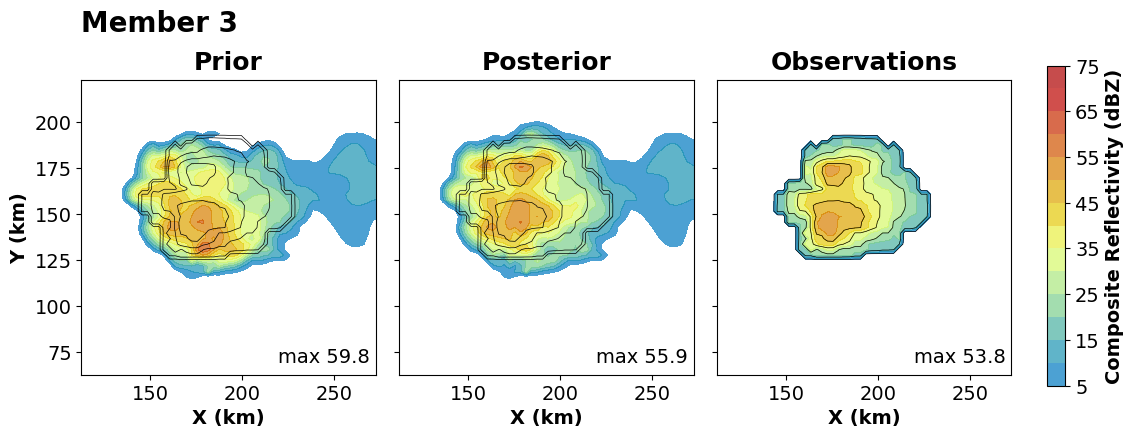

In [86]:
#MEMBER = 0

fpath = '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/test_w/'
name = fpath.split('/')[-2]
#TIME = 9

for TIME in [12]:#np.arange(10,21,2):

    for MEMBER in [3]:
    
        fig, axes= plt.subplots(1,3, figsize=(12, 4), sharex=True, sharey=True)
        
        
        # read in data
        if MEMBER == 0:
            fig.suptitle(f'Ensemble Mean',x=.19, fontsize=20, weight='bold', y=1.04)
            cm1 = xr.open_dataset(f'{fpath}member{MEMBER:03d}/cm1_post_{TIME:06d}.nc',decode_timedelta=True)
        else:
            fig.suptitle(f'Member {MEMBER}',x=.19, fontsize=20, weight='bold', y=1.04)
            cm1 = xr.open_dataset(f'{fpath}/member{MEMBER:03d}/cm1rst_{TIME:06d}.nc',decode_timedelta=True)

        try:
            prior = xr.open_dataset(f'{fpath}member{MEMBER:03d}/cm1_prior_{TIME:06d}.nc',decode_timedelta=True)
        except:
            print('no prior file, forecast only')
            prior=cm1.copy()
        
        analysis_time = DT.datetime(cm1.year, cm1.month, cm1.day, cm1.hour, cm1.minute)+DT.timedelta(seconds=int(cm1.time.values[0]/1e9))
        with contextlib.redirect_stdout(io.StringIO()) as f: # this just silences all the obnoxious output
            dbz_obs = get_dbz(analysis_time, fpath); # this is cref 
        
        for ax, data in zip(axes, [prior.dbz[0].max(axis=0).values, cm1.dbz[0].max(axis=0).values, dbz_obs[0]]):
            im=ax.contourf(cm1.xh/1000, cm1.yh/1000, data, levels=np.arange(5, 80, 5),cmap=ctables.REF_default, alpha=0.7)
            ax.text(0.98, 0.04, f'max {data.max():.1f}',ha='right', fontsize=14,transform=ax.transAxes )
            
        
        axes[0].set_ylabel('Y (km)')
        for ax, title in zip(axes, ['Prior', 'Posterior', 'Observations']):
            ax.set_title(title, y=1.01, weight='bold')
            ax.set_aspect('equal')
            ax.set_xlabel('X (km)')
            ax.contour(cm1.xh/1000, cm1.yh/1000, dbz_obs[:].max(axis=0), levels=np.arange(5, 80, 10),colors='k', linewidths=0.5)
    
            # center plots on max observations
            z,y,x = np.where(dbz_obs ==dbz_obs.max())
            cx = cm1.xh[x[0]]/1000; cy=cm1.yh[y[0]]/1000
            buf=80
            ax.set_xlim(cx-buf+20, cx+buf+20)
            ax.set_ylim(cy-buf, cy+buf)
    
        
        cbar_ax = fig.add_axes([0.93, 0.1, 0.015, 0.8])
        cbar = fig.colorbar(im, cax=cbar_ax)
        cbar.set_label('Composite Reflectivity (dBZ)', weight='bold')
        plt.subplots_adjust(wspace=0.08, hspace=0.3)
        plt.show()
        
        cm1.close()
        prior.close()

In [3]:
# look at stats files to make sure nothing is "blowing up"
# be very careful with this.... it may be locking the stats file and causing big problems for the experiments (?)
mem=3

fig=plt.figure(figsize=(12,8))

for mem in [2]:#np.arange(1,37,1):
    stats = xr.open_dataset(f'{fpath}/member{mem:03d}/cm1out_stats.nc',decode_timedelta=True)
    plt.plot(stats.time/1e9/60, stats.umax, label='Max U', ls='-',alpha=0.7, color='C4', lw=0.5)
    plt.plot(stats.time/1e9/60, stats.vmax, label='Max V', ls='-',alpha=0.7, color='C0', lw=.5)
    plt.plot(stats.time/1e9/60, stats.wmax, label='Max w', ls='-',alpha=0.7, color='k', lw=.5)
    plt.plot(stats.time/1e9/60, stats.maxqv, label='Max w', ls='-',alpha=0.7, color='r', lw=.5)
    for h in np.arange(45, 110, 5):
        plt.axvline(h, color='k', ls=':', lw=1)
    plt.xlabel('Time (Minutes')
    plt.ylabel('m/s')
    #plt.legend()
    stats.close()

NameError: name 'plt' is not defined

In [4]:
stats

<xarray.Dataset> Size: 41kB
Dimensions:   (xh: 1, yh: 1, zh: 1, time: 61)
Coordinates:
  * xh        (xh) float32 4B 0.0
  * yh        (yh) float32 4B 0.0
  * zh        (zh) float32 4B 0.0
  * time      (time) timedelta64[ns] 488B 00:00:00 00:01:00 ... 01:00:00
Data variables: (12/167)
    mtime     (time) float32 244B ...
    wmax      (time) float32 244B 0.9993 1.014 1.779 2.411 ... 18.68 19.47 19.51
    wmin      (time) float32 244B ...
    zwmax     (time) float32 244B ...
    zwmin     (time) float32 244B ...
    wmax500   (time) float32 244B ...
    ...        ...
    bscci     (time) float32 244B ...
    bscsw     (time) float32 244B ...
    bschw     (time) float32 244B ...
    bschl     (time) float32 244B ...
    bsvhw     (time) float32 244B ...
    bsvhl     (time) float32 244B ...
Attributes:
    CM1 version:    cm1r21.1
    Conventions:    CF-1.7
    missing_value:  -999999.9

In [6]:
#MEMBER = 0
#TIME = 11

for MEMBER in [4]:

    for TIME in np.arange(5, 28,2):

        fig, ax= plt.subplots(1,1, figsize=(4, 4), sharex=True, sharey=True)
        
        
        # read in data
        if MEMBER == 0:
            fig.suptitle(f'Ensemble Mean', fontsize=20, weight='bold', y=1.01)
            cm1 = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/RUN_LETKF/member{MEMBER:03d}/cm1_post_{TIME:06d}.nc',decode_timedelta=True)
        else:
            fig.suptitle(f'Member {MEMBER}', fontsize=20, weight='bold', y=1.01)
            cm1 = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/RUN_LETKF/member{MEMBER:03d}/cm1rst_{TIME:06d}.nc',decode_timedelta=True)
    
        im=ax.contourf(cm1.xh/1000, cm1.yh/1000, cm1.dbz[0].max(axis=0).values, levels=np.arange(10, 80, 5),cmap=ctables.REF_default, alpha=0.5)

        # try:
        #     analysis_time = DT.datetime(cm1.year, cm1.month, cm1.day, cm1.hour, cm1.minute)+DT.timedelta(seconds=int(cm1.time.values[0]/1e9))
        #     with contextlib.redirect_stdout(io.StringIO()) as f: # this just silences all the obnoxious output
        #         dbz_obs = get_dbz(analysis_time); # this is cref 
        #     ax.contour(cm1.xh/1000, cm1.yh/1000, dbz_obs[:].max(axis=0), levels=np.arange(10, 80, 10),colors='k', linewidths=0.5)
        # except:
        #     pass
        
        ax.text(0.98, 0.04, f'max {cm1.dbz[0].max():.1f}',ha='right', fontsize=14,transform=ax.transAxes )
        ax.set_ylabel('Y (km)')
        ax.set_aspect('equal')
        ax.set_xlabel('X (km)')
 
        cbar_ax = fig.add_axes([0.93, 0.1, 0.035, 0.8])
        cbar = fig.colorbar(im, cax=cbar_ax)
        cbar.set_label('Composite Reflectivity (dBZ)', weight='bold')
        plt.subplots_adjust(wspace=0.08, hspace=0.3)
        
        cm1.close()
    #prior.close()

array([   0.,   60.,  120.,  180.,  240.,  300.,  360.,  420.,  480.,
        540.,  600.,  660.,  720.,  780.,  840.,  900.,  960., 1020.,
       1080., 1140., 1200., 1260., 1320., 1380., 1440., 1500., 1560.,
       1620., 1680., 1740., 1800., 1860., 1920., 1980., 2040., 2100.,
       2160., 2220., 2280., 2340., 2400., 2460., 2520., 2580., 2640.,
       2700., 2760., 2820., 2880., 2940., 3000., 3060., 3120., 3180.,
       3240., 3300., 3360., 3420., 3480., 3540., 3600., 3660., 3720.,
       3780., 3840., 3900., 3960., 4020., 4080., 4140., 4200., 4260.,
       4320., 4380., 4440., 4500., 4560., 4620., 4680., 4740., 4800.,
       4860., 4920., 4980., 5040., 5100., 5160., 5220., 5280., 5340.,
       5400., 5460., 5520., 5580., 5640., 5700., 5760., 5820., 5880.,
       5940., 6000., 6060., 6120., 6180., 6240., 6300., 6360., 6420.,
       6480., 6540., 6600., 6660., 6720., 6780., 6840., 6900., 6960.,
       7020., 7080., 7140., 7200., 7260., 7320., 7380., 7440., 7500.,
       7560., 7620.,

In [ ]:
fig, axes = plt.subplots(3,4, figsize=(16, 10))

times = [dt.datetime(2024,5,8,21,40), dt.datetime(2024,5,8,22), dt.datetime(2024,5,8,22,30)]
exps = ['CI_15min', 'CI_10min', 'CI_5min']

height = 1000

# for ti, time in enumerate(times):

#     var = get_dbz_fast(time, f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exps[0]}', cref=False)[0]#[findnearest(z, height)]
#     axes[ti, 0].contourf(xh, yh, var,  cmap=ctables.REF_default, levels=np.arange(15,80,5))

    
    for ni, name in enumerate(exps):
        cm1 = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{name}/'

        if ni == 0:
            with open(f'{fpath}{name}.exp', 'rb') as f: exper = json.load(f)
            files = ens.FindRestartFiles(exper, time, ret_exp=False, prior=False)[0]
            z, yh, xh, var = get_mean_var(files, 'dbz', height=height, return_dims=True,return_all_dims=True)
        else:
            files = [f.replace(exps[ni-1], name) for f in files]
            var = get_mean_var(files, 'dbz', height=height)

        axes[ti, ni+1].contourf(xh, yh, var,  cmap=ctables.REF_default, levels=np.arange(15,80,5))

for ax in axes[:,-1]:
    ax.set_title('hi')

In [8]:
import datetime as dt

In [1]:
fig, axes = plt.subplots(3,4, figsize=(16, 10))

times = [dt.datetime(2024,5,8,21,40), dt.datetime(2024,5,8,22), dt.datetime(2024,5,8,22,30)]
exps = ['CI_15min', 'CI_10min', 'CI_5min']

for ni, exp in enumerate(exps[0:1]):
    cm1 = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/member000/fcst_mean.nc')
    cm1t = [pd.Timestamp(t) for t in cm1.time.values ]

    xh, yh = cm1.xh.values, cm1.yh.values

    for ni,t in enumerate(times):
        ti = findnearest(cm1t, t)
        axes[ti, ni].contourf(xh, yh, cm1.dbz[0],  cmap=ctables.REF_default, levels=np.arange(15,80,5))
        

NameError: name 'plt' is not defined

In [24]:
cm1t = [pd.Timestamp(t) for t in cm1.time.values ]
cm1t


np.int64(1)

In [22]:
pd.Timestamp(cm1.time.values[0])

Timestamp('2024-05-08 21:35:00')

# Delete files to redo DA experiments without having to re-run spin up

note: this may break your cm1out_stats files(?)

In [4]:
import sys
import os
import numpy as np
import math as M
import datetime as DT 
from netCDF4 import *
import glob
import json
sys.path.append('src/')
sys.path.append('src/fsrc/')
import ens

In [13]:
#### REDOING EXPERIMENTS - THIS ALLOWS YOU TO DELETE FROM A SPECIFIED LOCATION TO HELP WITH CM1 BUGS

ARE_YOU_SURE =True
experiment = 'eigen_test'

start_delete = DT.datetime(2024,5,8,20,30) # will delete all existing files after this time
experiment_location = f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{experiment}/'
#experiment_location = f'/work2/jessica.mcdonald/LETKF_work2/AllExperiments/{experiment}/'

exp_length = 240 # minutes... this doesn't have to be exact
outfile_freq = 3#10 # minutes... how often does cm1 output? 

with open(f'{experiment_location}letkf.exp', 'rb') as mf:
    exper = json.load(mf)


delete_list = []
# for i,rtime in enumerate(np.arange(start_delete, start_delete+DT.timedelta(minutes=exp_length+outfile_freq),DT.timedelta(minutes=outfile_freq) )):
#     rtime = rtime.astype(DT.datetime)

#     if i == 0: # find the cm1 ID for your specified start time, so you can loop over higher numbers
#         files, myDT = ens.FindRestartFiles(exper, rtime.strftime('%Y,%m,%d,%H,%M,%S'), ret_exp=False,)
#         start_num = int(files[0].split('.')[-2][-2:]) + 1 # you shouldn't delete that time step

#     inf = experiment_location+rtime.strftime('Inflation_%Y-%m-%d_%H:%M:%S.nc')
#     prior = experiment_location+rtime.strftime('Prior_%Y-%m-%d_%H:%M:%S.nc')
#     cm1out = experiment_location+'cm1.out'
#     delete_list.extend([inf, prior])

#start_num=35 # you can manually set the number if you'd prefer (and you don't care about inflation or prior files)
start_num=15
        
#for each member, get rid of anything after the start delete time      
for i in range(1, exper['ne']+1):
    main = experiment_location+f'member{i:03d}/'
    delete_list.append(main+f'cm1.out')
    for oi in range(start_num, int(exp_length/outfile_freq),1):
        delete_list.append(main+f'cm1rst_{oi:06d}.nc')
        if oi != start_num:# don't delete the prior, you'll move it to the rst position
            delete_list.append(main+f'cm1_prior_{oi:06d}.nc')
         
for d in delete_list:
    if os.path.exists(d):
        cmd = f'rm {d}'
        if ARE_YOU_SURE:
            os.system(cmd)
        else:            
            print(cmd)      

# # now replace the restart files with the prior files so you can pick back up where you started!
for i in range(1, exper['ne']+1):
    main = experiment_location+f'member{i:03d}/'
    # mv the prior file back to the rst position
    prior = main+f'cm1_prior_{start_num:06d}.nc'
    rst = prior.replace('_prior', 'rst')
    cmd = f'mv {prior} {rst}'
    if ARE_YOU_SURE:
        os.system(cmd)
    else:            
        print(cmd) 

mv: cannot stat '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member001/cm1_prior_000015.nc': No such file or directory
mv: cannot stat '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member002/cm1_prior_000015.nc': No such file or directory
mv: cannot stat '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member003/cm1_prior_000015.nc': No such file or directory
mv: cannot stat '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member004/cm1_prior_000015.nc': No such file or directory
mv: cannot stat '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member005/cm1_prior_000015.nc': No such file or directory
mv: cannot stat '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member006/cm1_prior_000015.nc': No such file or directory
mv: cannot stat '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member007/cm1_prior_000015.nc': No such file or directory
mv: cannot stat '/work/jessica.mcdonald/CM1_LETK

# eigen tests

In [79]:
# step1, make directory
exp_name = 'new_eigen_test'
orig = 'C3_5L09_R3'
cm1f = 27

base_dir =  f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp_name}'
os.system(f'mkdir {base_dir}')


cm1file = f'cm1rst_{cm1f:06d}.nc'

old = f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{orig}'
# copy all cm1 stuff over
for f in ['onefile.F', 'namelist.input', 'LANDUSE.TBL']:
    cmd = f'cp {os.path.join(old, f)} {base_dir}'
    os.system(cmd)


# make member directory, link namelist
for member in range(1, 37):
    # make member dictionary 
    memb = f'member{member:03d}'
    cmd = f'mkdir {os.path.join(base_dir, memb)}'
    os.system(cmd)

    mem = os.path.join(test, memb)
    pri = os.path.join(old,  memb)

    for f in ['cm1.exe', 'onefile.F', 'LANDUSE.TBL', cm1file]:
        
        cmd = f'cp {os.path.join(pri, f)} {os.path.join(mem, f)}'
        os.system(cmd)

    # relink
    os.chdir(os.path.join(base_dir, f'member{member:03d}'))
    os.system(f'ln -s ../namelist.input namelist.input')


cp: '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C3_5L09_R3/member001/onefile.F' and '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member001/onefile.F' are the same file
cp: '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C3_5L09_R3/member001/LANDUSE.TBL' and '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member001/LANDUSE.TBL' are the same file
cp: '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C3_5L09_R3/member002/onefile.F' and '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member002/onefile.F' are the same file
cp: '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C3_5L09_R3/member002/LANDUSE.TBL' and '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member002/LANDUSE.TBL' are the same file
cp: '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C3_5L09_R3/member003/onefile.F' and '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member003/onefile.F' are the same file
cp: '/work/jessica.mcdonald/CM1_

In [76]:
# now copy over json file and rename 
fjson = glob.glob(os.path.join(old, '*.exp'))[0]
with open(fjson, 'rb') as f:exper= json.load(f)

for var in ['base_dir', 'namelist', 'base_path', 'fcst_path', 'plots_path']: 
    exper[var] = exper[var].replace(old, base_dir)

# then do forecast members
fcst_mems = []
for f in exper['fcst_members']:
    fcst_mems.append(f.replace(old, base_dir))
exper['fcst_members'] = fcst_mems

njson = 
with open(njson, 'w') as f: json.dump(exper, f)

'member036'

In [67]:
test =  f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/'
orig =  f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C3_5L07_R5/'
n = 14
for member in range(1, 37):
    # copy prior from orig, rename as posterior in test
    mem = os.path.join(test, f'member{member:03d}', f'cm1rst_{n:06d}.nc')
    pri = os.path.join(orig,f'member{member:03d}', f'cm1rst_{n:06d}.nc')
    cmd = f"cp {pri} {mem} "
    os.system(cmd)
    #print(cmd)

In [22]:
test =  f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/'
for member in range(1, 37):
    m = os.path.join(test, f'member{member:03d}')
    print(m)
    os.chdir(m)
    os.system('rm namelist.input')
    os.system(f'ln -s ../namelist.input namelist.input')
    #os.system(f'cp ../../CI_3min/{os.path.basename(m)}/cm1_prior_000016.nc {m}/cm1rst_000016.nc')

/work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member001
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member002
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member003
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member004
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member005
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member006
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member007
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member008
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member009
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member010
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member011
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member012
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member013
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member014
/work/

In [68]:
base_dir = f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/'
src = '/work/jessica.mcdonald/CM1_LETKF_2025/src/'
exp_name = f'{base_dir}/letkf.exp' 
assim_freq = 180
freq = 180
ncores = 64
time_dt = DT.datetime(2024, 5, 8, 20, 36)
time = time_dt.strftime('%Y,%m,%d,%H,%M,%S')

os.chdir(src)

os.system(f"python run_fcst.py -e {exp_name} --run_time {assim_freq} --freq {freq}  -t {time} --ncores {ncores}" )

_variable_dbz_error = False

analysis_time = time_dt


 ==> RUN_FCST: Date&time supplied: 2024 05-08 20:36:00, which corresponds to a local model time of 3960 sec

 Run_Fcst Script:  defaulting to 1 threads

 Run_Fcst Script:  64 cores requested....

 Run_Fcst Script: Number ensemble members to run not supplied, defaulting to experiment file:  36

 Run_Fcst Script: Integrating 036 ensemble members for 0180 seconds

 Found time 3960 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member001/cm1rst_000014.nc
14

 Found time 3960 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member001/cm1rst_000014.nc

 Now setting up forecast member: /work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member001
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member001/cm1.exe is the model path
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member001/cm1.out is the outputfile path

 Now setting up forecast member: /work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/me

 READ_NAMELIST: PROBLEM WITH NSSL_MP_PARAMS namelist: not found or bad token
--------------------------------------------------------------------------
MPI_ABORT was invoked on rank 0 in communicator MPI_COMM_WORLD
  Proc: [[55433,1],0]
  Errorcode: 128

NOTE: invoking MPI_ABORT causes Open MPI to kill all MPI processes.
You may or may not see output from other processes, depending on
exactly when Open MPI kills them.
--------------------------------------------------------------------------
--------------------------------------------------------------------------
prterun has exited due to process rank 0 with PID 0 on node wof-epyc9 calling
"abort". This may have caused other processes in the application to be
terminated by signals sent by prterun (as reported here).
--------------------------------------------------------------------------
  READ_NAMELIST: PROBLEM WITH NSSL_MP_PARAMS namelist: not found or bad token
 READ_NAMELIST: PROBLEM WITH NSSL_MP_PARAMS namelist: not found or b


 Executing command:  cd /work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member001 ; mpirun -n 64 cm1.exe >> cm1.out 

 cd /work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member001 ; mpirun -n 64 cm1.exe >> cm1.out completed....

 Executing command:  cd /work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member002 ; mpirun -n 64 cm1.exe >> cm1.out 

 cd /work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member002 ; mpirun -n 64 cm1.exe >> cm1.out completed....

 Executing command:  cd /work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member003 ; mpirun -n 64 cm1.exe >> cm1.out 

 cd /work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member003 ; mpirun -n 64 cm1.exe >> cm1.out completed....

 Executing command:  cd /work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member004 ; mpirun -n 64 cm1.exe >> cm1.out 

 cd /work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member004 ; mpirun -n 64 cm1.exe >> cm

 READ_NAMELIST: PROBLEM WITH NSSL_MP_PARAMS namelist: not found or bad token
 READ_NAMELIST: PROBLEM WITH NSSL_MP_PARAMS namelist: not found or bad token
 READ_NAMELIST: PROBLEM WITH NSSL_MP_PARAMS namelist: not found or bad token
 READ_NAMELIST: PROBLEM WITH NSSL_MP_PARAMS namelist: not found or bad token



 Executing command:  cd /work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member033 ; mpirun -n 64 cm1.exe >> cm1.out 

 cd /work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member033 ; mpirun -n 64 cm1.exe >> cm1.out completed....

 Executing command:  cd /work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member034 ; mpirun -n 64 cm1.exe >> cm1.out 

 cd /work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member034 ; mpirun -n 64 cm1.exe >> cm1.out completed....

 Executing command:  cd /work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member035 ; mpirun -n 64 cm1.exe >> cm1.out 

 cd /work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member035 ; mpirun -n 64 cm1.exe >> cm1.out completed....

 Executing command:  cd /work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member036 ; mpirun -n 64 cm1.exe >> cm1.out 

 cd /work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member036 ; mpirun -n 64 cm1.exe >> cm

In [54]:
from nc_prior_file import *
sys.path.append( "fsrc/" )
from fpython2 import fstate

In [60]:
with open(f'{base_dir}letkf.exp', 'rb') as mf:
    exper = json.load(mf)

mpass               = exper['DA_PARAMS']['mpass']
writeFcstMean       = exper['DA_PARAMS']['writeFcstMean']
writeAnalMean       = exper['DA_PARAMS']['writeAnalMean']
saveWeights         = exper['DA_PARAMS']['saveWeights']
readWeights         = exper['DA_PARAMS']['readWeights']
rhoriz              = exper['DA_PARAMS']['rhoriz']
rvert               = exper['DA_PARAMS']['rvert']
rtime               = exper['DA_PARAMS']['rtime']
cutoff              = exper['DA_PARAMS']['cutoff']
zcutoff             = exper['DA_PARAMS']['zcutoff']
prior_inflate       = exper['DA_PARAMS']['prior_inflate'] 
prior_inflate_value = exper['DA_PARAMS']['prior_inflate_value']
post_inflate        = exper['DA_PARAMS']['post_inflate']  
post_inflate_alpha  = exper['DA_PARAMS']['post_inflate_alpha']
outlier_threshold   = exper['DA_PARAMS']['outlier']
inlier_threshold    = exper['DA_PARAMS']['inlier']
readWeights         = exper['DA_PARAMS']['readWeights']
saveWeights         = exper['DA_PARAMS']['saveWeights']
nthreads            = exper['DA_PARAMS']['nthreads']
path=base_dir

ftime      = time_dt#DT.datetime(int(time[0]),int(time[1]),int(time[2]),int(time[3]),int(time[4]),int(time[5]))
prior_file = os.path.join(path, "Prior_%s.nc" % ftime.strftime("%Y-%m-%d_%H:%M:%S"))

inflation_deltaT = exper['DA_PARAMS']['assim_freq'] # JESSMCDO EDIT: i changes this from "assim_window" to "assim_freq" because that seemed more
                                                            # appropriate, also I changed assim_window and so the two are no longer equal
dt = DT.timedelta(0,inflation_deltaT)

in_time = time_dt - dt
inflate_file = os.path.join(path, "Inflation_%s.nc" % in_time.strftime("%Y-%m-%d_%H:%M:%S"))

_time_units    = 'seconds since 1970-01-01 00:00:00'
_calendar      = 'standard'
tanalysis = date2num(analysis_time,units=_time_units,calendar=_calendar)
analysis_sec = date2num(analysis_time,units=_time_units,calendar=_calendar)
update_theta = 1

In [45]:
#analysis_time = DT.datetime(int(time[0]),int(time[1]),int(time[2]),int(time[3]),int(time[4]),int(time[5]))
    
files, exper = ens.FindRestartFiles(exper, analysis_time, ret_DT=False)

print(("\n  ---->LETKF:  Reading in model state for analysis at %s \n" %  (analysis_time.strftime("%Y %m-%d %H:%M:%S"))))

state = ens.read_CM1_ens(files, exper, state_vector = None, DateTime=analysis_time, addmean=1)   
ens.ens_CM1_coords(state)
ens.ens_CM1_mean(state)



 ==> FindRestartFiles: Date and time supplied is 2024_05_08 20:39:00

 ==> FindRestartFile:  Found time 4140 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/member001/cm1rst_000015.nc

  ---->LETKF:  Reading in model state for analysis at 2024 05-08 20:39:00 


 ==> READ_CM1_ENS:  No state_vector supplied - trying to match microphysics schemes

 ==> READ_CM1_ENS ==> Matching state_vector found !!! using zvdh

 ==> READ_CM1_ENS: reading from time INDEX:  0
 ==> READ_CM1_ENS: reading from state TIME:  2024-05-08 20:39:00 


 Wallclock time for serial read netCDF ensemble files: 6.379  sec

 Wallclock time to convert from C to A grid: 0.794  sec

 Wallclock time to create ensemble means: 1.267  sec

 Wallclock time to read arrays from netCDF ensemble files: 9.193  sec

 Wallclock time to create coordinates: 0.036  sec

 Wallclock time to create ensemble means: 1.268  sec


In [62]:

kind, value, error, lat, lon, xob, yob, zob, tob, Hxf, Hxfbar, outlier = read_prior(analysis_time, file=prior_file, sort=True)
    
nobs = Hxf.shape[0]
ne   = Hxf.shape[1]

if nobs == 0:  
    print(("\n  ----> LETKF:  Prior file is empty, exiting at analysis time %s \n" %  (analysis_time.strftime("%Y %m-%d %H:%M:%S"))))
    sys.exit(0)
else:
    print(("\n  ----> LETKF:  Prior file has %d obs at analysis time %s \n" %  (nobs, analysis_time.strftime("%Y %m-%d %H:%M:%S"))))
    
    tob = np.array(tob - analysis_sec, dtype=np.float64)   # departure time for temporation localization
    
    if (outlier_threshold > 0):
        print(('\n  --> LETKF called with an outlier threshold of %d standard deviations' % outlier_threshold))
        
        mask  = np.where( (outlier <= outlier_threshold) & (outlier >= inlier_threshold), True, False )
        
        #mask = np.where( ((kind !=13) & (outlier <= outlier_threshold)) | ((kind==13) & (outlier >= 0.25)), True, False ) # only outliers for DBZ and VR, only inliers for DBZ0
        
        
        kind   = kind[mask]
        value  = value[mask]
        error  = error[mask]
        tob    = tob[mask]
        xob    = xob[mask]
        yob    = yob[mask]
        zob    = zob[mask]
        Hxf    = Hxf[mask][:]
        Hxfbar = Hxfbar[mask]
        lat    = lat[mask]
        lon    = lon[mask]
        
        print('\n  >=====================================================================<')
        print(('\n  --> LETKF:  Number of total    obs = %d' % nobs))
        print(('\n  --> LETKF:  Number of rejected obs = %d' % (nobs - np.count_nonzero(mask) )))
        print(('\n  --> LETKF:  Max outlier: %f  Min outlier:  %f\n' % (outlier.max(), outlier.min())))
        
        # Reset number of obs
        
        nobs = np.count_nonzero(mask)

        # Change the dbz error threshold based on each obs innovation mean 
        if _variable_dbz_error:
            mask = np.where( kind == 12, True, False )
            print("  --> LETKF:  Variable dBZ error:  Number of dBZ observations is %d" % np.count_nonzero(mask))
            mask2 = np.where(value > 20., True, False)
            print("  --> LETKF:  Variable dBZ error:  Number of obs where value > 20  %d" % np.count_nonzero(mask2))
            mask  = mask & mask2
            print("  -->  LETKF:  Number of Priors where Obs > 20 and will have their values increased:  %d" % np.count_nonzero(mask))
            Hxfbar[mask] = Hxfbar[mask] + 10.
            Hxf[mask,:] = Hxf[mask,:] + 10.

# Recompute coordinate system of x/y's based from the SW corner (lat,lon) of model grid.
# The observations' new x/y's are then in the model's coordinate system relative to reference (lat,lon) of grid
# Need to do this again because of running-in-place for moving grids...

xob, yob = pyDart.dll_2_dxy(state.late[0], lat, state.lone[0], lon, degrees=True)
dep      = np.zeros(nobs)
dep[:]   = value[:] - Hxfbar[:]

# Here we create the localization arrays

rdiag    = np.array(error.reshape(nobs,1), order='F')
rloc     = np.array(np.ones(nobs).reshape(nobs,1), order='F')

inflate_array = read_inflation_file(file=inflate_file)

Prior obs file found, opening /work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/Prior_2024-05-08_20:39:00.nc 

Total number of obs in /work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/Prior_2024-05-08_20:39:00.nc file is 8443 


  ----> LETKF:  Prior file has 8443 obs at analysis time 2024 05-08 20:39:00 


  --> LETKF called with an outlier threshold of 3 standard deviations

  >=====================================================================<

  --> LETKF:  Number of total    obs = 8443

  --> LETKF:  Number of rejected obs = 1154

  --> LETKF:  Max outlier: 16.138357  Min outlier:  0.000000



In [63]:
inflateN = fstate.compute_letkf(xob, yob, zob, tob, tanalysis,
                                    value, Hxf, dep, rdiag, rloc, 
                                    rhoriz, rvert, rtime, nthreads, cutoff, zcutoff, update_theta, 
                                    prior_inflate, inflate_array, post_inflate, post_inflate_alpha,
                                    saveWeights, readWeights)

 COMPUTE_LETKF:  NX/NY/NZ/NE:            128         128          52          37
 COMPUTE_LETKF:  NOBS:                  7289
 COMPUTE_LETKF:  X_OB Max/Min:     379666.50216698798        15139.022745438384     
 COMPUTE_LETKF:  Y_OB Max/Min:     375250.00196136528        15250.001961365015     
 COMPUTE_LETKF:  Z_OB Max/Min:     24684.748382397414        107.65700788516870     
 COMPUTE_LETKF:  T_OB Max/Min:     0.0000000000000000        0.0000000000000000     
 COMPUTE_LETKF:  T_Analysis:       1715200740.0000000     
 COMPUTE_LETKF:  X_GD Max/Min:     382500.000       1500.00000    
 COMPUTE_LETKF:  Y_GD Max/Min:     382500.000       1500.00000    
 COMPUTE_LETKF:  Z_GD Max/Min:     24700.0000       100.000000    
 COMPUTE_LETKF:  RHORIZ:           7500.0000000000000     
 COMPUTE_LETKF:  RVERT:            4500.0000000000000     
 COMPUTE_LETKF:  RTIME:           -600.00000000000000     
 COMPUTE_LETKF:  Hx shape               7289          36
 COMPUTE_LETKF:  UPDATE THETA FLAG:     

In [11]:
python letkf.py --exper /work/jessica.mcdonald/CM1_LETKF_2025/experiments/eigen_test/letkf.exp --time 2024,05,08,20,39,00 --nthreads 8 --noupdate

'member036'

In [12]:
namelist

'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_3min_10min/namelist.input'

In [13]:
import xarray as xr
temp = xr.open_dataset('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_2min/member020/cm1_prior_000025.nc', decode_timedelta=True)

In [21]:
import os
import datetime as dt
import numpy as np
import glob
import json
import ens


import sys
# sys.path.append('../run/')
# import forecast_namelist as namelist
# os.chdir('../src/') # back to original directory

sys.path.append('run/')
sys.path.append('src/')
sys.path.append('../')
import forecast_namelist as namelist
# os.chdir('../src/') # back 

def linkit(dir_from_target,dir_to_target,link_option):
    '''from create_run_letkf'''
    
    if debug: print(f"LINKIT:  ARG[0]: {dir_from_target}  ARG[1]:  {dir_to_target}")
    if link_option == 0:  return

    from_path = dir_from_target
    to_path   = dir_to_target

    if link_option == 1:
        LINK_CMD =f"ln -s {from_path} {to_path}" 
        
        if os.system(LINK_CMD) != 0:
            print(f"\n ERROR!!!\n ERROR!!! FAILIED TO EXECUTE: {LINK_CMD}\n ERROR!!!")
            sys.exit(1)
            
        print("Linked " + dir_from_target + " to directory  " + dir_to_target)

      
    if link_option == 2:
        CP_CMD = f"cp  {from_path} {to_path}" 
        
        if os.system(CP_CMD) != 0:
            print(f"\n ERROR!!!\n ERROR!!! FAILIED TO EXECUTE: {LINK_CMD}")
            if not os.path.exists(dir_from_target):
                print(f"\nCOMMAND FAILED because {dir_from_target} does not exist\n ")
            elif not os.path.join(dir_to_target):
                print(f"COMMAND FAILED because{dir_to_target} does not exist\n ")
            else:
                print("\nBOTH FILE AND DIRECTORY EXISTS....something else f__ked up here....\n")
            print("ERROR!!!\n") 
            sys.exit(1)
            
        print(f"Copied {dir_from_target} to directory {dir_to_target}")

    return

ModuleNotFoundError: No module named 'fpython2'

In [2]:
# directory that your existing experiment is in
base_dir             = namelist.base_dir
ncores               = namelist.ncores
forecast_freq        = namelist.forecast_freq
forecast_start       = namelist.forecast_start
forecast_end         = namelist.forecast_end
forecast_launch_freq = namelist.forecast_launch_freq # seconds. if more than zero, a new forecast will be launched at the time interval specified here
same_end_time        = namelist.same_end_time 

name = base_dir.split('/')[-1]
exp_name = f'{base_dir}/{name}.exp' # name of json file with all of the experiment info

# open experiment file to get experiment info
with open(exp_name, 'rb') as f: exper = json.load(f)

In [3]:
if forecast_launch_freq != 0:
    dtime = dt.timedelta(seconds=forecast_launch_freq)
    times = np.arange(forecast_start, forecast_end+ dtime, dtime)
else:
    times = [forecast_start]

if same_end_time:
    forecast_len = (forecast_end - forecast_start).seconds
else:
    forecast_len = namelist.forecase_len

In [20]:
for var in ['model', 'src', 'landsfc', 'namelist']:
    print(os.path.basename(exper[var]))

cm1.exe
onefile.F
LANDUSE.TBL
namelist.input


In [19]:
exper

{'base_dir': '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_3min_10min',
 'fprefix': 'cm1',
 'ne': 36,
 'model': 'cm1r21v1/run/cm1.exe',
 'src': 'cm1r21v1/run/onefile.F',
 'namelist': '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_3min_10min/namelist.input',
 'landsfc': 'cm1r21v1/run/LANDUSE.TBL',
 'sounding': 'soundings/',
 'radar_obs': '/work/jessica.mcdonald/CM1_LETKF_2025/run/observations/8may24_cm1_5km_obs.csv',
 'YEAR': 2024,
 'MONTH': 5,
 'DAY': 8,
 'HOUR': 19,
 'MINUTE': 30,
 'SECOND': 0,
 'lat0': 35.23583,
 'lon0': -97.46194,
 'hgt': 0,
 'xoffset': -180000.0,
 'yoffset': -180000.0,
 'microphysics': 'zvdh',
 'cook_period': 1800,
 'cook_freq': 300,
 'forecast_length': 3600,
 'forecast_freq': 300,
 'INIT': {'nb': 3,
  'tpert': 3.0,
  'wpert': 1.0,
  'tdpert': 0.0,
  'qvpert': 5.0,
  'upert': 0.0,
  'vpert': 0.0,
  'centerx': 120000.0,
  'centery': 100000.0,
  'max_x_offset': 20000.0,
  'max_y_offset': 20000.0,
  'zbmin': 0.0,
  'zbmax': 1500.0,
  'rbubh': 10000.0,
 

In [14]:

# loop over the times

for time in times:

    

mkdir /work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_3min_10min/FORECAST_20240508_2030
mkdir /work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_3min_10min/FORECAST_20240508_2030/member001
mkdir /work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_3min_10min/FORECAST_20240508_2030/member002
mkdir /work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_3min_10min/FORECAST_20240508_2030/member003
mkdir /work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_3min_10min/FORECAST_20240508_2030/member004
mkdir /work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_3min_10min/FORECAST_20240508_2030/member005
mkdir /work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_3min_10min/FORECAST_20240508_2030/member006
mkdir /work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_3min_10min/FORECAST_20240508_2030/member007
mkdir /work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_3min_10min/FORECAST_20240508_2030/member008
mkdir /work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_3min_10min/FORECAST_2024

In [12]:
exper['ne']

36

In [4]:
exp_name

'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_3min_10min/CI_3min_10min.exp'